# Implementing The Cnn In Tensorflow

### ---Data Loading

In [13]:
import struct
import numpy as np
import os


def load_idx(filename):
    with open(filename, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8)
        return data.reshape(num, rows, cols)

def load_labels(filename):
    with open(filename, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
        return labels

# Load data
loc_path = os.getcwd()
x_train_full = load_idx(loc_path + '\\Datasets\\train-images.idx3-ubyte') / 255.0
y_train_full = load_labels(loc_path + '\\Datasets\\train-labels.idx1-ubyte')

x_test = load_idx(loc_path + '\\Datasets\\t10k-images.idx3-ubyte') / 255.0
y_test = load_labels(loc_path + '\\Datasets\\t10k-labels.idx1-ubyte')

# Use a subset for quick training
x_train = x_train_full#[:1000]
y_train = y_train_full#[:1000]


In [14]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten, MaxPooling2D

model = Sequential(
    [
        Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1)),
        MaxPooling2D((2,2)),
        Conv2D(64, kernel_size =(3,3), activation="relu"),
        Flatten(),
        Dense(128, activation="relu"),
        Dense(64, activation="relu"),
        Dense(10,activation= "softmax")       
    ]

)

c:\Users\david_bbnm\tensorflow\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Setting model optimizer and evaluation

In [15]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"]
              )
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 7744)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       991,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,019,082 (3.89 MB)

 Trainable params: 1,019,082 (3.89 MB)

 Non-trainable params: 0 (0.00 B)

### Training

In [16]:
history = model.fit(x_train, y_train, epochs=4, batch_size=32)

Epoch 1/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 23ms/step - accuracy: 0.9627 - loss: 0.1219
Epoch 2/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.9871 - loss: 0.0428
Epoch 3/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 91s 28ms/step - accuracy: 0.9911 - loss: 0.0289
Epoch 4/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9935 - loss: 0.0206


### Evaluation

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print("Test accuracy:", int(test_acc))

313/313 - 3s - 11ms/step - accuracy: 0.9885 - loss: 0.0354
Test accuracy: 0.9884999990463257


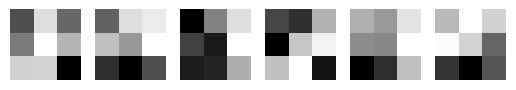

In [22]:
import matplotlib.pyplot as plt
import numpy as np

layer = model.layers[0]   # first Conv2D layer
filters, biases = layer.get_weights()

# Plot first 6 filters
n_filters = 6
for i in range(n_filters):
    f = filters[:, :, 0, i]   # take channel 0
    plt.subplot(1, n_filters, i+1)
    plt.imshow(f, cmap='gray')
    plt.axis('off')
plt.show()


### Are CNN Black Boxes?

**Kinda.**

Convolutional Neural Networks (CNNs) are often called *black boxes* because:
- They contain millions of parameters that are hard to interpret directly.
- We see inputs (images) and outputs (predictions), but the internal decision process isn’t obvious.
- Filters and activations don’t always map neatly to human‑understandable concepts.

But CNNs are **not completely opaque**:
- We can **visualize filters** (`layer.get_weights()`) to see what patterns are being learned.
- We can **inspect feature maps** (activations) to understand how an image transforms layer by layer.
- Tools like **Grad‑CAM** and **saliency maps** highlight which pixels influenced a decision.
- Early layers tend to learn simple features (edges, textures), while deeper layers capture complex shapes and patterns.